Dataset Shape: (569, 30)

First 5 Rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst 

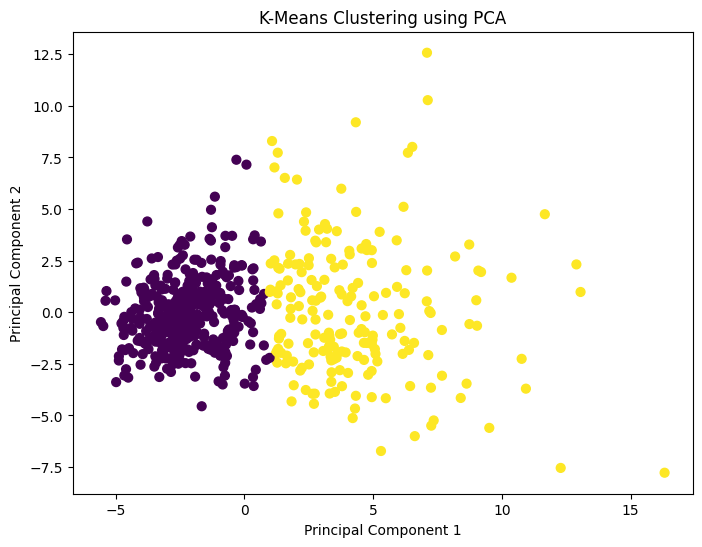


Model Evaluation
Accuracy: 0.9825

Confusion Matrix:
[[41  1]
 [ 1 71]]

Precision: 0.9861
Recall: 0.9861
F1 Score: 0.9861
ROC-AUC: 0.9954

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


5-Fold Cross Validation
Individual Scores:
Fold 1 : 0.9825
Fold 2 : 0.9825
Fold 3 : 0.9737
Fold 4 : 0.9737
Fold 5 : 0.9912
Mean CV Accuracy: 0.9807

Hyperparameter Tuning
Best Parameters:
{'C': 0.1, 'solver': 'lbfgs'}
Best Cross-Validation Score: 0.9802

Final Model Accuracy: 0.9737

Final Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                  

In [1]:


# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    silhouette_score
)

# ============================================
# 1. Load Dataset
# ============================================

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Dataset Shape:", X.shape)
print("\nFirst 5 Rows:")
print(X.head())

# ============================================
# 2. Standardize Data
# ============================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nData standardized successfully.")

# ============================================
# 3. K-Means Clustering
# ============================================

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("\nK-Means Clustering")
print("------------------")
print("Cluster labels:")
print(kmeans_labels[:20])

# Silhouette Score
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

print("K-Means Silhouette Score:",
      round(kmeans_silhouette, 4))

# ============================================
# 4. Hierarchical Clustering
# ============================================

hierarchical = AgglomerativeClustering(n_clusters=2)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

print("\nHierarchical Clustering")
print("-----------------------")
print("Cluster labels:")
print(hierarchical_labels[:20])

hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print("Hierarchical Silhouette Score:",
      round(hierarchical_silhouette, 4))

# ============================================
# 5. Dimensionality Reduction using PCA
# ============================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nPCA")
print("---")
print("Original number of features:", X.shape[1])
print("Reduced number of features:", X_pca.shape[1])

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    round(sum(pca.explained_variance_ratio_) * 100, 2),
    "%"
)

# ============================================
# 6. Visualize K-Means Clusters
# ============================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=40
)

plt.title("K-Means Clustering using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

# ============================================
# 7. Classification Model
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)[:, 1]

# ============================================
# 8. Accuracy
# ============================================

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Evaluation")
print("================")

print("Accuracy:",
      round(accuracy, 4))

# ============================================
# 9. Confusion Matrix
# ============================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# ============================================
# 10. Precision
# ============================================

precision = precision_score(y_test, y_pred)

print("\nPrecision:",
      round(precision, 4))

# ============================================
# 11. Recall
# ============================================

recall = recall_score(y_test, y_pred)

print("Recall:",
      round(recall, 4))

# ============================================
# 12. F1 Score
# ============================================

f1 = f1_score(y_test, y_pred)

print("F1 Score:",
      round(f1, 4))

# ============================================
# 13. ROC-AUC
# ============================================

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC:",
      round(roc_auc, 4))

# ============================================
# 14. Classification Report
# ============================================

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

# ============================================
# 15. Cross Validation
# ============================================

cv_scores = cross_val_score(
    model,
    X_scaled,
    y,
    cv=5,
    scoring="accuracy"
)

print("\n5-Fold Cross Validation")
print("=======================")

print("Individual Scores:")

for i, score in enumerate(cv_scores, 1):
    print(
        "Fold", i,
        ":",
        round(score, 4)
    )

print(
    "Mean CV Accuracy:",
    round(cv_scores.mean(), 4)
)

# ============================================
# 16. Hyperparameter Tuning
# ============================================

parameter_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    parameter_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("\nHyperparameter Tuning")
print("=====================")

print("Best Parameters:")
print(grid_search.best_params_)

print(
    "Best Cross-Validation Score:",
    round(grid_search.best_score_, 4)
)

# ============================================
# 17. Final Model Evaluation
# ============================================

best_model = grid_search.best_estimator_

final_predictions = best_model.predict(X_test)

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

print("\nFinal Model Accuracy:",
      round(final_accuracy, 4))

print("\nFinal Classification Report:")
print(
    classification_report(
        y_test,
        final_predictions,
        target_names=data.target_names
    )
)

